In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [3]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none'
sns.set_theme(
    style="white",
    context="notebook",
    font_scale=1.2
)

In [4]:
df = pd.read_csv("../../data/training_data.csv")

/tmp/ipykernel_25288/557058051.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[ax_index].set_yticklabels([12, 14, 16, 18, 20, 22, 24, 26, 28, 30],**kwargs_ticks)
/tmp/ipykernel_25288/557058051.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[ax_index].set_yticklabels([0, 10, 20, 30, 40, 50, 60, 70, 80, 90],**kwargs_ticks)


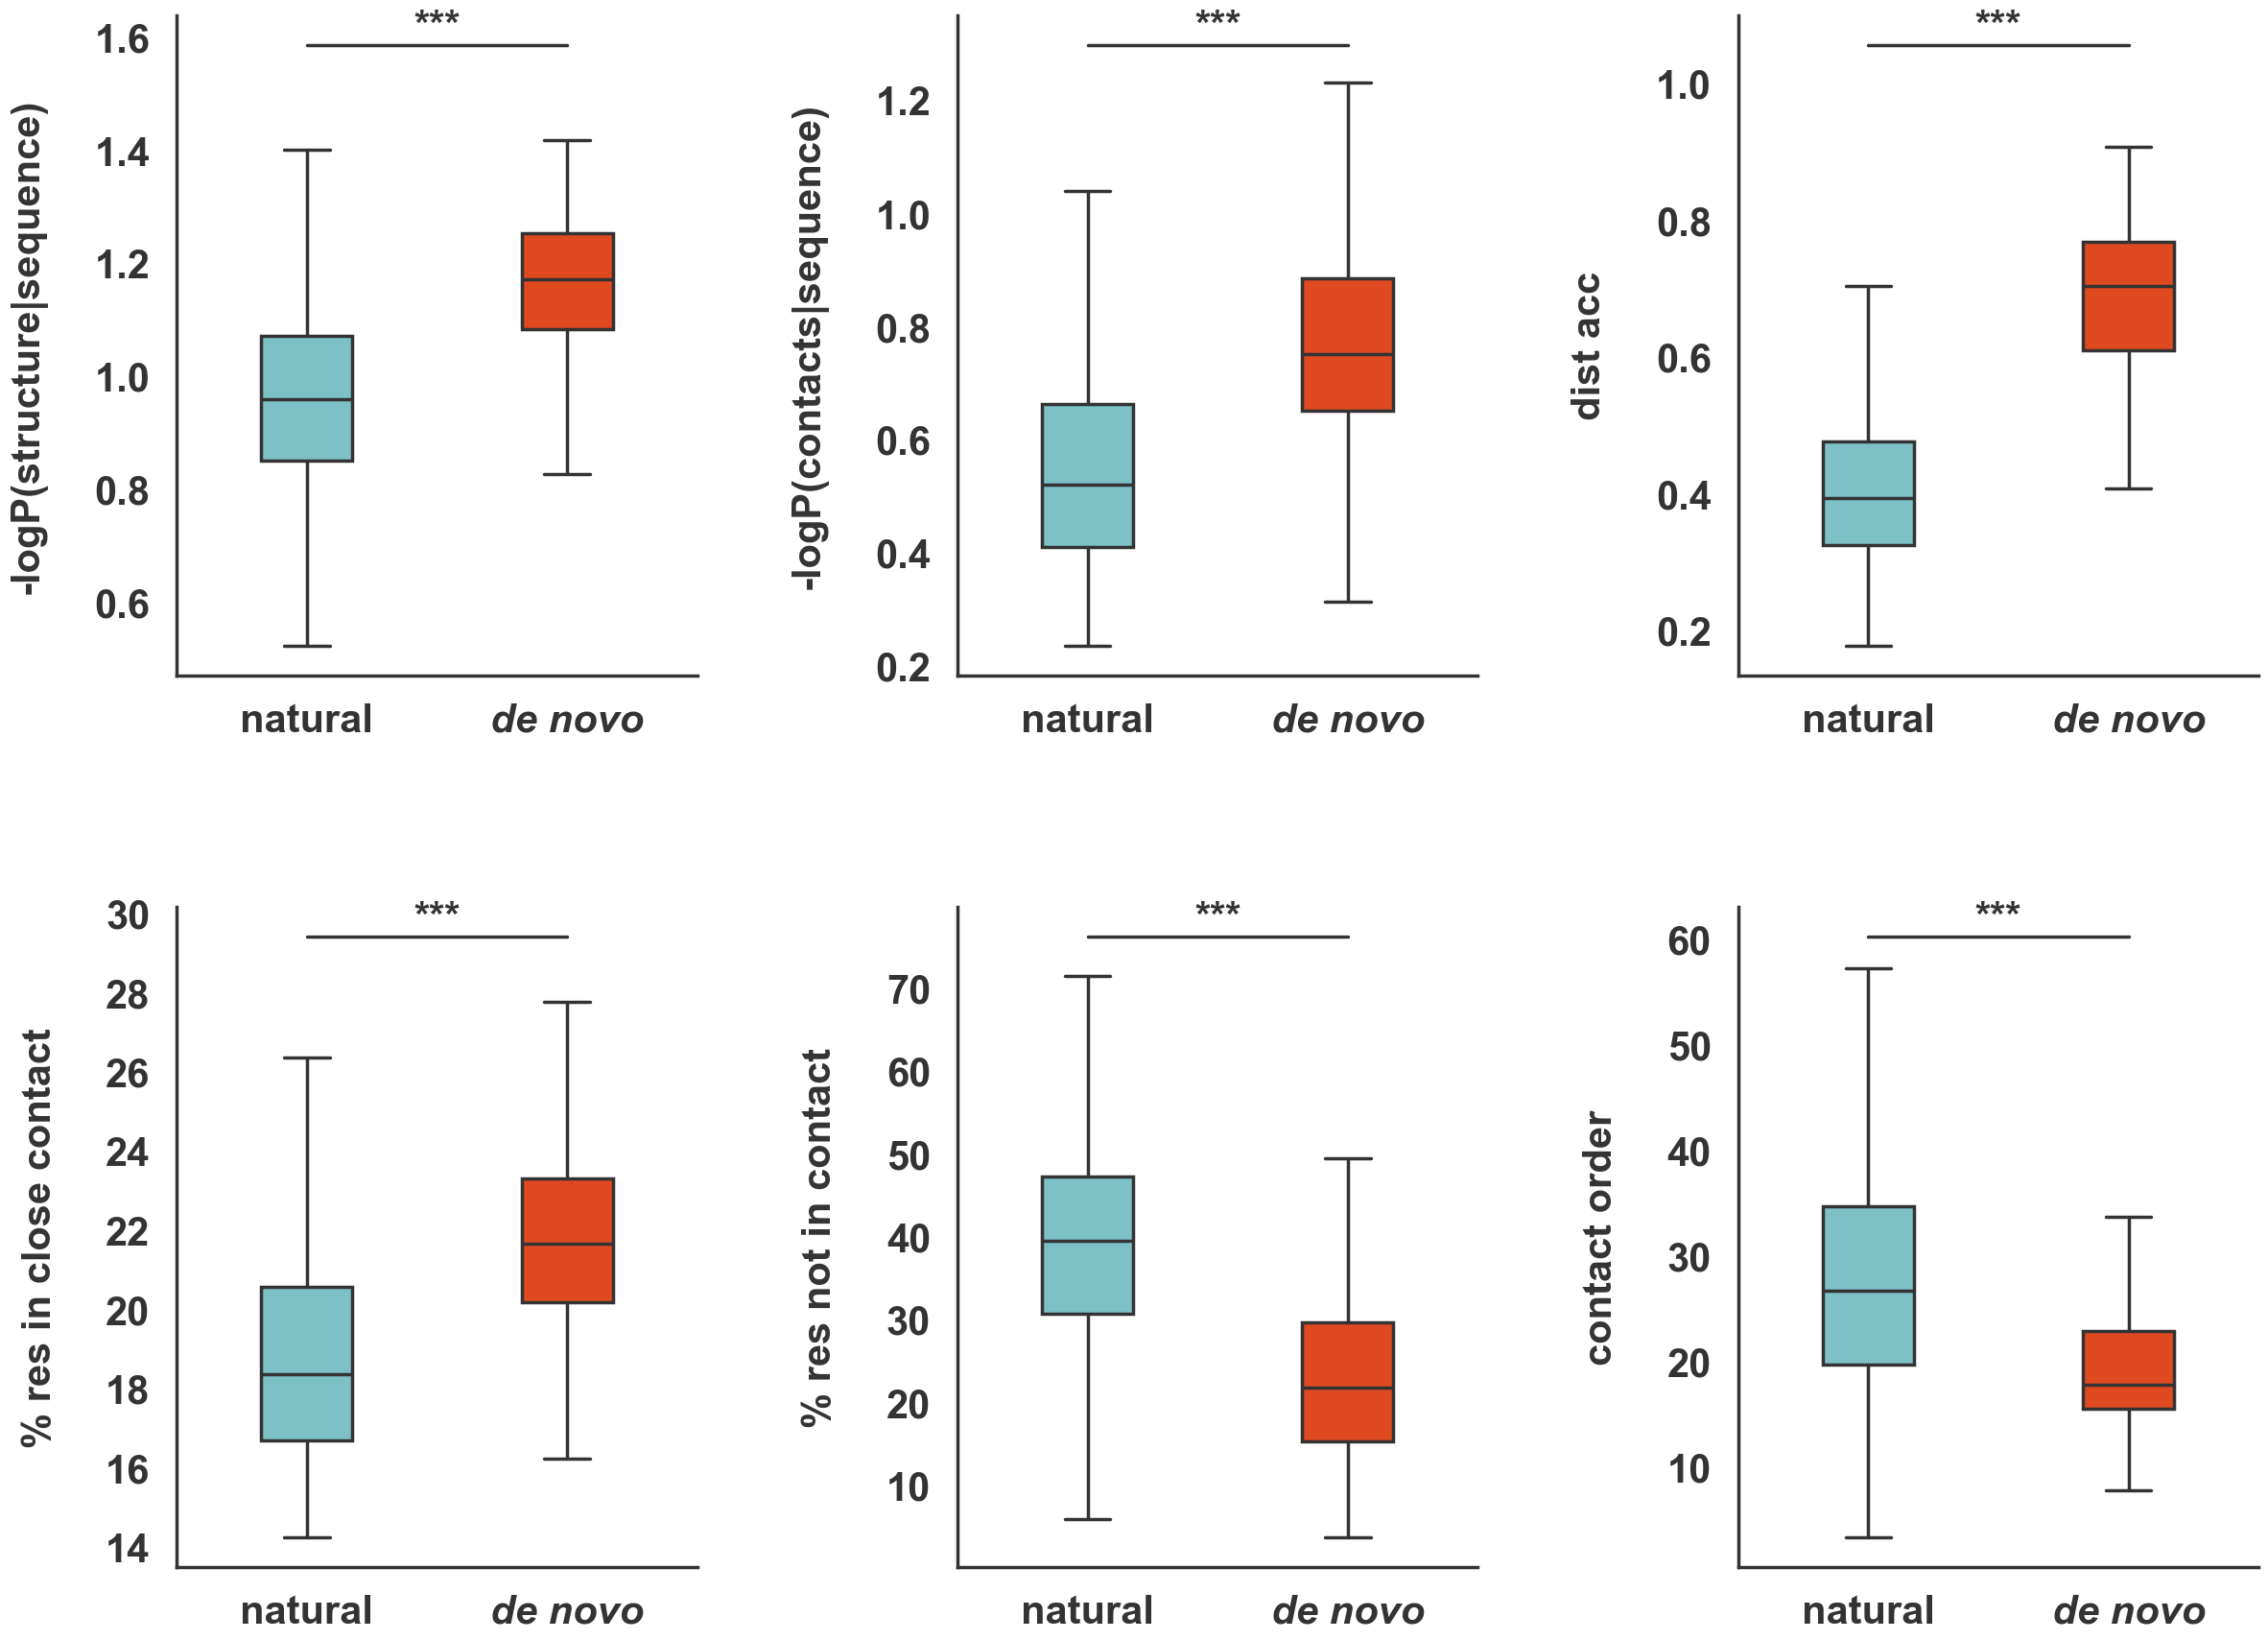

In [13]:
custom_palette = ['#71cbd3','#ff3700']
STD_COLOR='0.2'

metrics=['-logP_Struc','-logP_Contact',"area_sc",'per_con','per_no_con','contact_order']
title=['-logP(structure|sequence)','-logP(contacts|sequence)',"dist acc",'% res in close contact','% res not in contact','contact order']

kwargs_title={'fontsize':35, 'weight':'bold', 'color':STD_COLOR}
kwargs_label={'fontsize':30, 'weight':'bold', 'color':STD_COLOR}
kwargs_ticks={'fontsize':30, 'weight':'bold', 'color':STD_COLOR}
kwargs_box={'boxprops':{ 'edgecolor':STD_COLOR,'zorder':2}}


fig, ax = plt.subplots(2,3,figsize=(28,21))

for n, (metric, title) in enumerate(zip(metrics,title)):
    name = metric.replace("_"," ")
    
    ax_index=n // 3, n % 3

    # print(metric)
    to_plot=metric


    sns.boxplot(x='type',hue='type',y=to_plot,data=df,linewidth=2.5,width=.35,showfliers=False,palette=custom_palette, ax=ax[ax_index],legend=False,**kwargs_box) 
    ax[ax_index].set_xlim(-0.5, 1.5)
    if metric == 'per_no_con':
        ax[ax_index].set_yticklabels([0, 10, 20, 30, 40, 50, 60, 70, 80, 90],**kwargs_ticks)  
    
    if metric == 'per_con':
        ax[ax_index].set_yticklabels([12, 14, 16, 18, 20, 22, 24, 26, 28, 30],**kwargs_ticks)
        
    for line in ax[ax_index].lines:
        line.set_color(STD_COLOR) 

    ax[ax_index].set_ylabel(f'{title}\n',**kwargs_label)
    ax[ax_index].set_xlabel('')
    ax[ax_index].set_title('')
    ax[ax_index].set_xticks([0,1])
    # ax[ax_index].set_yticks(ax[ax_index].get_yticks())

    ax[ax_index].set_xticklabels(['natural','de novo'],**kwargs_label)
    my_denovo= ax[ax_index].xaxis.get_ticklabels()[1]
    my_denovo.set_style('italic')
    
    yticks_locs, yticks_labels = ax[ax_index].get_yticks(), ax[ax_index].get_yticklabels()
    for label in yticks_labels:
        label.set_color(STD_COLOR)
        label.set_weight('bold')
        label.set_fontsize(30)


    for axis in ['bottom','left','top','right']:
        ax[ax_index].spines[axis].set_linewidth(2.5)
        ax[ax_index].spines[axis].set_color(STD_COLOR)

    ax[ax_index].spines['top'].set_visible(False)
    ax[ax_index].spines['right'].set_visible(False)
    ax[ax_index].tick_params(width=2.5,length=10,pad=10, color=STD_COLOR)

    
    
    plt.subplots_adjust(hspace=0.35,wspace=0.5) 
        
    # Calculate the upper border of the IQR
    Q1_0 = df[df['type'] == 0][to_plot].quantile(0.25)
    Q3_0 = df[df['type'] == 0][to_plot].quantile(0.75)
    IQR_0 = Q3_0 - Q1_0
    upper_border_0 = Q3_0 + 1.5 * IQR_0
    
    Q1_1 = df[df['type'] == 1][to_plot].quantile(0.25)
    Q3_1 = df[df['type'] == 1][to_plot].quantile(0.75)
    IQR_1= Q3_1 - Q1_1
    upper_border_1 = Q3_1 + 1.5 * IQR_1
    
    upper_border=max(upper_border_0,upper_border_1)

    y, h = upper_border + upper_border*0.05, 0
    ax[ax_index].plot([0, 0, 1, 1], [y, y+h, y+h, y], lw=2.5, c=STD_COLOR,clip_on=False)
    

    p_val = mannwhitneyu(df[df['type'] == 0][to_plot],df[df['type'] == 1][to_plot]).pvalue
    
    
    
    if p_val < .0005:
        ax[ax_index].text((0+1)*.5, y+h, "***", ha='center', va='bottom', color=STD_COLOR,fontdict={'fontsize':30,'weight':'bold'})
    elif p_val < .005:
        ax[ax_index].text((0+1)*.5, y+h, "**", ha='center', va='bottom', color=STD_COLOR,fontdict={'fontsize':30,'weight':'bold'})
    elif p_val < .05:
        ax[ax_index].text((0+1)*.5, y+h, "*", ha='center', va='bottom', color=STD_COLOR,fontdict={'fontsize':30,'weight':'bold'})
    else:
        ax[ax_index].text((0+1)*.5, y+h, "n.s.", ha='center', va='bottom', color=STD_COLOR,fontdict={'fontsize':30,'weight':'bold'})
        

        
plt.savefig('./feature.svg',dpi=300,bbox_inches='tight')